In [94]:
#!pip install seaborn
#!pip install nbformat>=4.2.0
#!pip install  plotly

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
test = pd.read_csv('higgs-boson/test/test.csv')
dataset = pd.read_csv('higgs-boson/training/training.csv')

In [5]:
test.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,350000,-999.000,79.589,23.916,3.036,-999.000,-999.000,-999.000,0.903,3.036,...,2.022,98.556,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000
1,350001,106.398,67.490,87.949,49.994,-999.000,-999.000,-999.000,2.048,2.679,...,-1.138,176.251,1,47.575,-0.553,-0.849,-999.000,-999.000,-999.000,47.575
2,350002,117.794,56.226,96.358,4.137,-999.000,-999.000,-999.000,2.755,4.137,...,-1.868,111.505,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
3,350003,135.861,30.604,97.288,9.104,-999.000,-999.000,-999.000,2.811,9.104,...,1.172,164.707,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
4,350004,74.159,82.772,58.731,89.646,1.347,536.663,-0.339,1.028,77.213,...,-0.231,869.614,3,254.085,-1.013,-0.334,185.857,0.335,2.587,599.213


In [6]:
dataset.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   EventId                      250000 non-null  int64  
 1   DER_mass_MMC                 250000 non-null  float64
 2   DER_mass_transverse_met_lep  250000 non-null  float64
 3   DER_mass_vis                 250000 non-null  float64
 4   DER_pt_h                     250000 non-null  float64
 5   DER_deltaeta_jet_jet         250000 non-null  float64
 6   DER_mass_jet_jet             250000 non-null  float64
 7   DER_prodeta_jet_jet          250000 non-null  float64
 8   DER_deltar_tau_lep           250000 non-null  float64
 9   DER_pt_tot                   250000 non-null  float64
 10  DER_sum_pt                   250000 non-null  float64
 11  DER_pt_ratio_lep_tau         250000 non-null  float64
 12  DER_met_phi_centrality       250000 non-null  float64
 13 

In [8]:
from utils.data import DataManager

data_manager = DataManager()
data_manager.preparar_conjuntos()

X, y = data_manager.get_X_y()
weights = data_manager.get_weights()
X = X.drop(['Weight', 'Label'], axis=1)
event_id = dataset['EventId']
X.set_index('EventId')

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
EventId,,,,,,,,,,,,,,,,,,,,,
100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497
100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,125.157,...,-1.916,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226
100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,197.814,...,-2.186,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251
100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,75.968,...,0.060,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000
100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,57.983,...,-0.871,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,55.892,...,2.859,144.665,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000
349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,50.618,...,-0.867,80.408,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000
349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,120.462,...,-2.890,198.907,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992


In [9]:
X.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,-0.277,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,-1.916,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,-2.186,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0.060,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,-0.871,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000


In [10]:
y=pd.Series(y)
y.head()

0    1
1    0
2    0
3    0
4    0
dtype: int32

In [11]:
weights.head()

0    0.002653
1    2.233584
2    2.347389
3    5.446378
4    6.245333
Name: Weight, dtype: float64

In [103]:
!mkdir Fotos-A-Datos

Ya existe el subdirectorio o el archivo Fotos-A-Datos.


# Exploración de datos

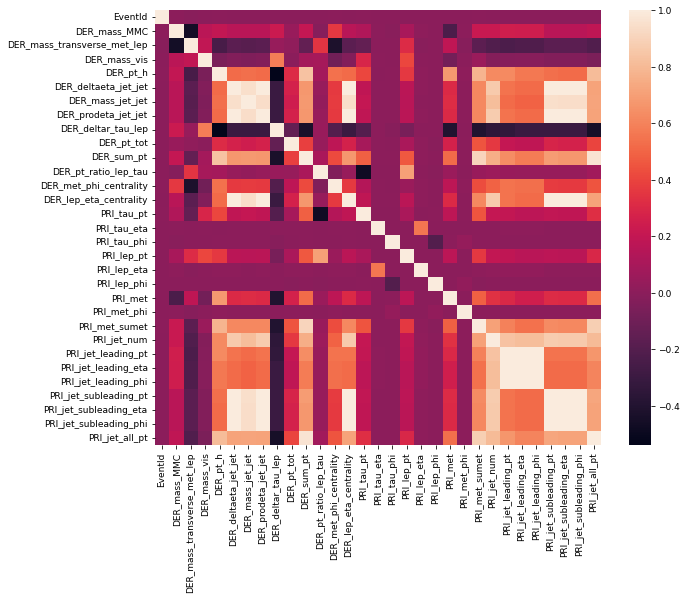

In [12]:
corr_matrix = X.corr()
plt.figure(figsize = (10,8))
plt.rcParams.update({'font.size': 9})
sns.color_palette("rocket", 8)
ax = sns.heatmap(data= corr_matrix,fmt=".1f")
plt.show()

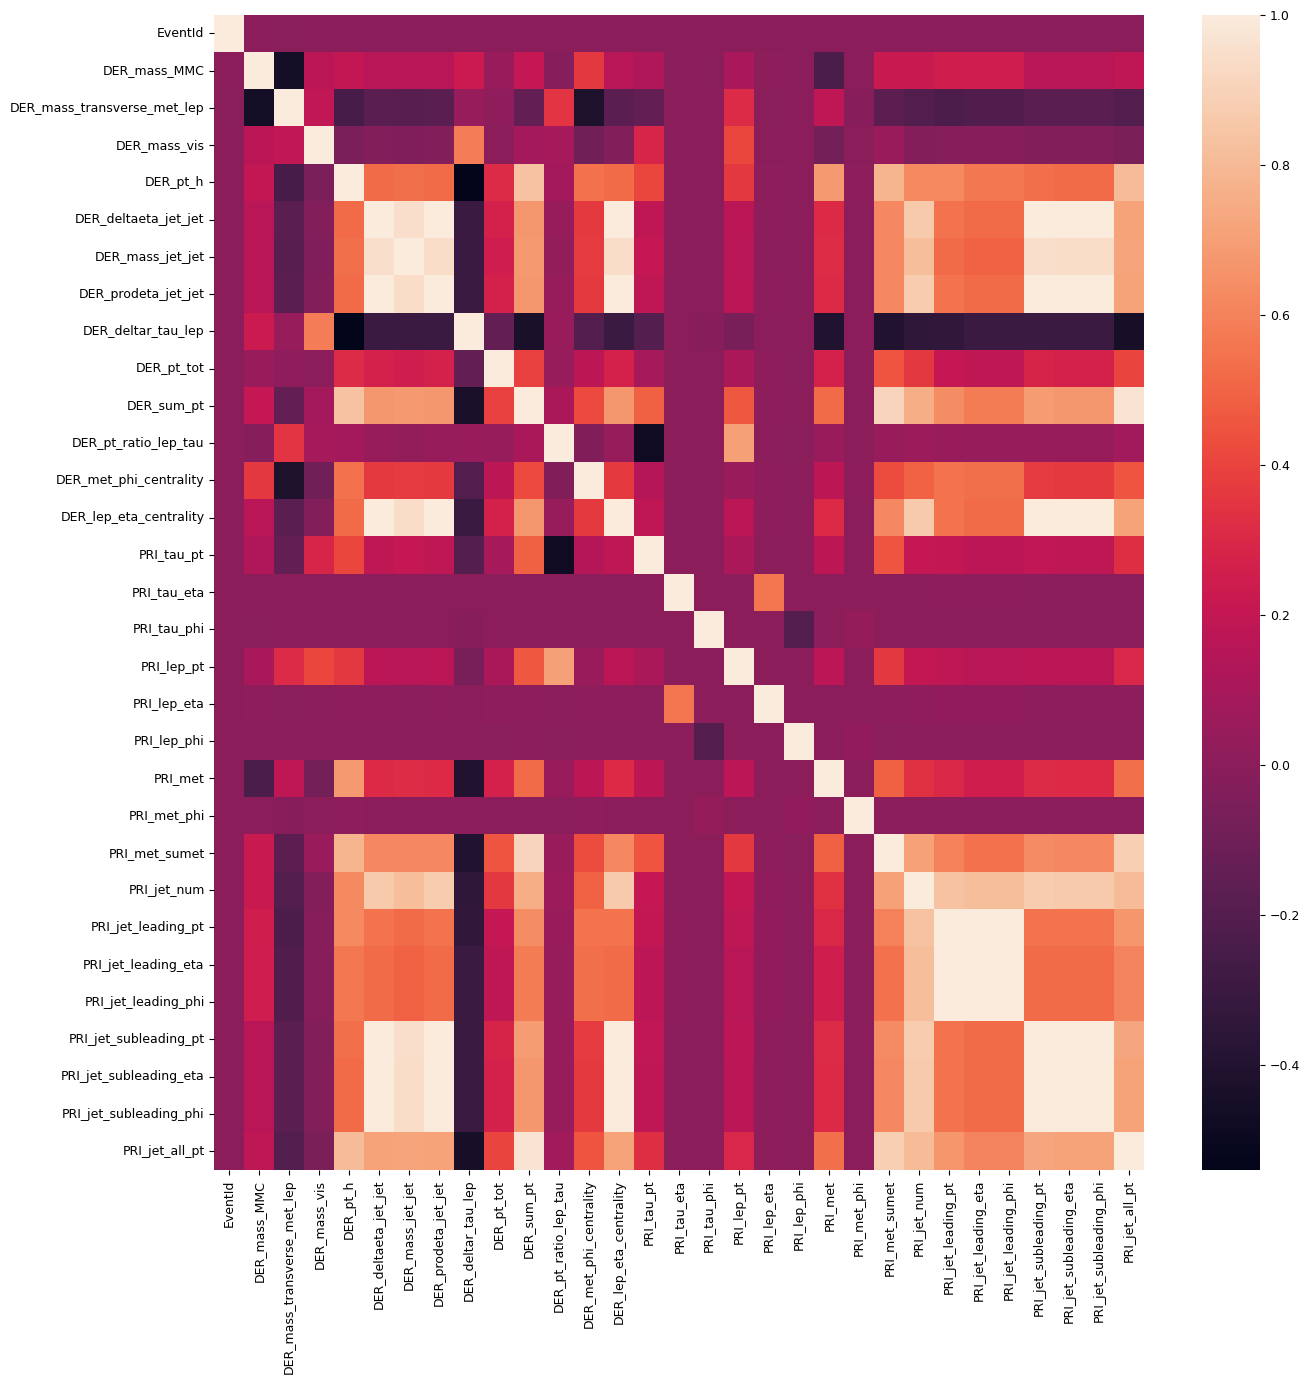

In [13]:
corr_matrix = X.corr()
plt.figure(figsize = (15,15))
plt.rcParams.update({'font.size': 9})
sns.color_palette("rocket", 8)
ax = sns.heatmap(data= corr_matrix) # fmt=".2f", annot=True si queremos que se vean los valores
#plt.savefig('Fotos-A-Datos/corr_heatmap.png')
plt.show()

In [14]:
corr_matrix["DER_pt_h"].sort_values(ascending=False)

DER_pt_h                       1.000000
DER_sum_pt                     0.832733
PRI_jet_all_pt                 0.808616
PRI_met_sumet                  0.782547
PRI_met                        0.679585
PRI_jet_num                    0.623401
PRI_jet_leading_pt             0.621599
PRI_jet_leading_eta            0.564898
PRI_jet_leading_phi            0.564894
DER_met_phi_centrality         0.539356
DER_mass_jet_jet               0.534531
PRI_jet_subleading_pt          0.531647
DER_lep_eta_centrality         0.523720
PRI_jet_subleading_eta         0.523714
PRI_jet_subleading_phi         0.523703
DER_deltaeta_jet_jet           0.523664
DER_prodeta_jet_jet            0.523639
PRI_tau_pt                     0.407421
PRI_lep_pt                     0.360939
DER_pt_tot                     0.310501
DER_mass_MMC                   0.198765
DER_pt_ratio_lep_tau           0.089187
PRI_met_phi                    0.008585
PRI_lep_eta                    0.008354
PRI_tau_phi                    0.005248


In [15]:
corr_matrix["DER_prodeta_jet_jet"].sort_values(ascending=False)

DER_prodeta_jet_jet            1.000000
DER_lep_eta_centrality         0.999990
PRI_jet_subleading_phi         0.999989
PRI_jet_subleading_eta         0.999988
DER_deltaeta_jet_jet           0.999981
PRI_jet_subleading_pt          0.999347
DER_mass_jet_jet               0.944443
PRI_jet_num                    0.867741
PRI_jet_all_pt                 0.712620
DER_sum_pt                     0.672158
PRI_met_sumet                  0.619388
PRI_jet_leading_pt             0.545022
DER_pt_h                       0.523639
PRI_jet_leading_phi            0.521661
PRI_jet_leading_eta            0.521653
DER_met_phi_centrality         0.368177
PRI_met                        0.305678
DER_pt_tot                     0.271435
PRI_tau_pt                     0.187936
PRI_lep_pt                     0.168270
DER_mass_MMC                   0.162521
DER_pt_ratio_lep_tau           0.041614
PRI_lep_eta                    0.008692
PRI_met_phi                    0.005254
PRI_tau_eta                    0.004880


In [16]:
X.replace(-999, np.nan, inplace=True)

DATOS FALTANTES POR CATEGORÍA


<Axes: title={'center': 'DATOS FALTANTES POR CATEGORÍA'}>

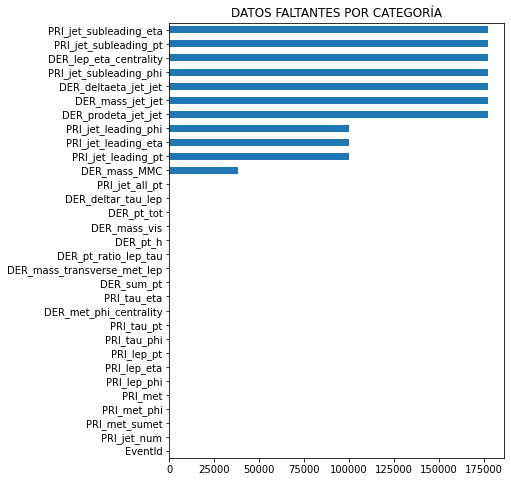

In [17]:
print('DATOS FALTANTES POR CATEGORÍA')
plt.rcParams.update({'font.size': 10})
plt.title('DATOS FALTANTES POR CATEGORÍA')
X_null_as = X.isnull().sum().sort_values(ascending=True)
X_null_as.plot(kind = "barh", figsize=(6, 8))

In [47]:
corr_matrix_without_nan = X.corr()
corr_matrix_without_nan

<Axes: title={'center': 'DATOS FALTANTES POR CATEGORÍA'}>

## DISTRIBUCIÓN EXPONENCIAL

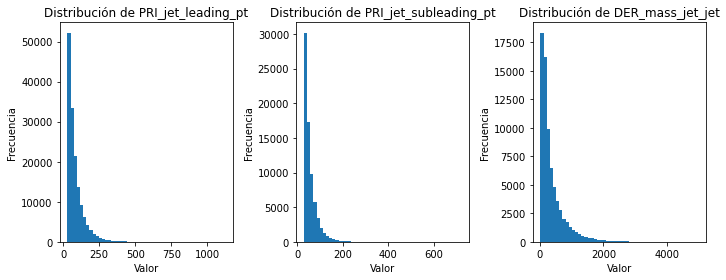

In [45]:
n_bins = 50
axes1 = X['PRI_jet_leading_pt']
axes2 = X['PRI_jet_subleading_pt']
axes3 = X['DER_mass_jet_jet']
plt.rcParams.update({'font.size': 10})
fig, axes = plt.subplots(nrows=1, ncols=3,  figsize=(10, 4), tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axes[0].hist(axes1, bins=n_bins)
axes[0].set_title("Distribución de PRI_jet_leading_pt")
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[1].set_title("Distribución de PRI_jet_subleading_pt")
axes[1].hist(axes2, bins=n_bins)
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
axes[2].set_title("Distribución de DER_mass_jet_jet")
axes[2].hist(axes3, bins=n_bins)
axes[2].set_xlabel('Valor')
axes[2].set_ylabel('Frecuencia')

plt.savefig('Fotos-A-Datos/Distribucion_exponencial.png')

## DISTRIBUCIÓN NORMAL

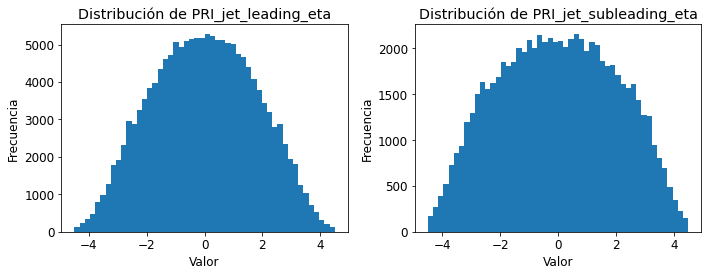

<Figure size 432x288 with 0 Axes>

In [46]:
n_bins = 50
axes1 = X['PRI_jet_leading_eta']
axes1_std = axes1.std()
axes2 = X['PRI_jet_subleading_eta']
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(nrows=1, ncols=2,  figsize=(10, 4), tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axes[0].hist(axes1, bins=n_bins)
axes[0].set_title("Distribución de PRI_jet_leading_eta")
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[1].set_title("Distribución de PRI_jet_subleading_eta")
axes[1].hist(axes2, bins=n_bins)
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')
plt.show()

plt.savefig('Fotos-A-Datos/Distribucion_normal.png')

## DISTRIBUCIÓN UNIFORME

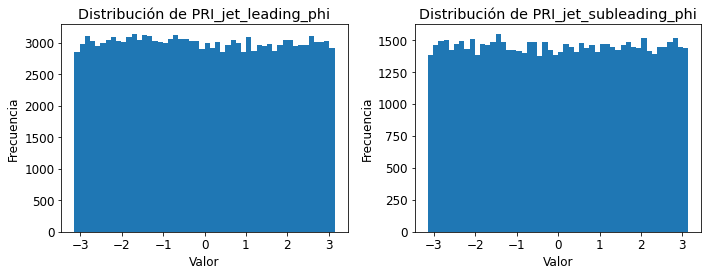

In [48]:
n_bins = 50
axes1 = X['PRI_jet_leading_phi']
axes2 = X['PRI_jet_subleading_phi']
plt.rcParams.update({'font.size': 12})
fig, axes = plt.subplots(nrows=1, ncols=2,  figsize=(10, 4), tight_layout=True)

# We can set the number of bins with the *bins* keyword argument.
axes[0].hist(axes1, bins=n_bins)
axes[0].set_title("Distribución de PRI_jet_leading_phi")
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[1].set_title("Distribución de PRI_jet_subleading_phi")
axes[1].hist(axes2, bins=n_bins)
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frecuencia')

plt.savefig('Fotos-A-Datos/Distribucion_uniforme.png')

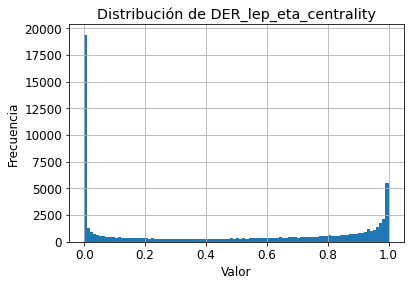

<Figure size 432x288 with 0 Axes>

In [49]:
attr = X['DER_lep_eta_centrality']
attr.hist(bins=100)
plt.title('Distribución de DER_lep_eta_centrality')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()
plt.savefig('Fotos-A-Datos/DER_lep_eta_centrality.png')

In [50]:
print(min(X['DER_lep_eta_centrality']))

0.0


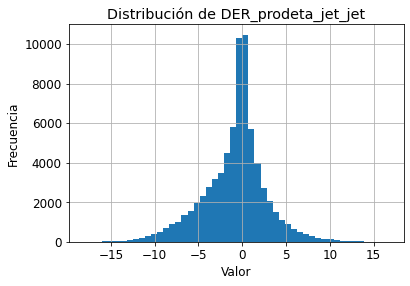

<Figure size 432x288 with 0 Axes>

In [51]:
X['DER_prodeta_jet_jet'].hist(bins=50)
plt.title('Distribución de DER_prodeta_jet_jet')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()
plt.savefig('Fotos-A-Datos/DER_prodeta_jet_jet.png')

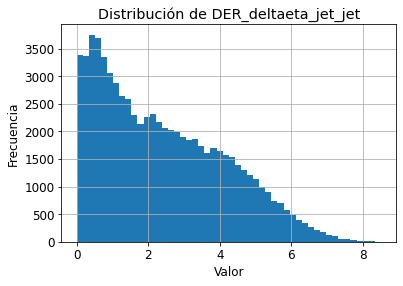

<Figure size 432x288 with 0 Axes>

In [52]:
X['DER_deltaeta_jet_jet'].hist(bins=50)
plt.title('Distribución de DER_deltaeta_jet_jet')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.show()
plt.savefig('Fotos-A-Datos/DER_deltaeta_jet_jet.png')

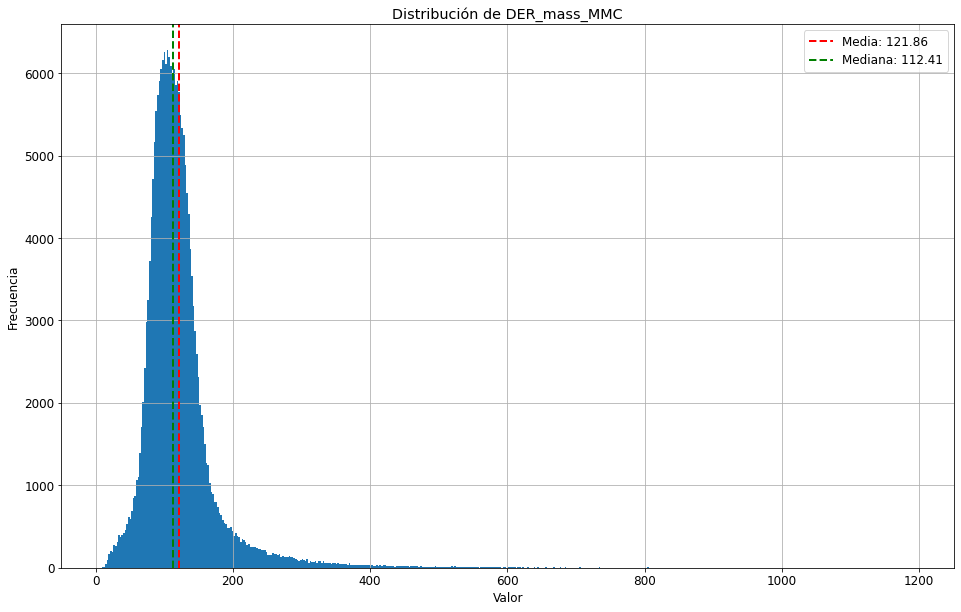

<Figure size 432x288 with 0 Axes>

In [53]:
plt.figure(figsize=(16,10))
X['DER_mass_MMC'].hist(bins=500)
plt.title('Distribución de DER_mass_MMC')
plt.xlabel('Valor')
plt.ylabel('Frecuencia')

media = X['DER_mass_MMC'].mean()
mediana = X['DER_mass_MMC'].median()

plt.axvline(media, color='r', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='g', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana:.2f}')


plt.legend()
plt.show()
plt.savefig('Fotos-A-Datos/DER_mass_MMC.png')

In [37]:
!pip install nbformat>=4.2.0


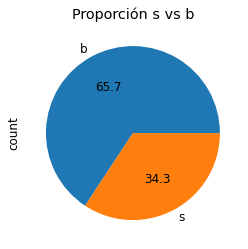

In [54]:
ax= y.value_counts().plot.pie(autopct='%.1f')
ax.set_title('Proporción s vs b')
plt.savefig('Fotos-A-Datos/desbalance.png')